# Paper-faithful Linear Weights GA for *Can't Stop*

This notebook implements the **Linear Weights Genome** from Glenn & Aloi's paper
*A Generalized Heuristic for Can't Stop*.

The important difference from the previous version is that this notebook uses a **bit-string genome**, not loose continuous parameters.

The genome is:

$$
(p_2,\dots,p_7,\ m_2,\dots,m_7,\ b_2,\dots,b_7,\ e,\ o,\ h,\ k,\ t)
$$

where:
- $p_i$: progress weights
- $m_i$: linear slope for move weights
- $b_i$: linear intercept for move weights
- $e$: all-even difficulty score
- $o$: all-odd difficulty score
- $h$: all-high and all-low difficulty score
- $k$: marker penalty
- $t$: stopping threshold

The paper uses symmetry, so only columns $2,\dots,7$ are encoded directly.
Columns $8,\dots,12$ are mirrored automatically.


## Paper reference

The linear genome follows the paper's description of the second genome:

- progress parameters $p_2,\dots,p_7$
- move slopes $m_2,\dots,m_7$
- move intercepts $b_2,\dots,b_7$
- difficulty scores and threshold
- bit-string operators
- double-point crossover
- bit-flip mutation with probability $0.04$

The linear move weight is:

$$
x_{ij} = \left\lfloor m_i \frac{j}{l_i} + b_i \right\rfloor
$$


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

COLUMNS = list(range(2, 13))

HEIGHT = {
    2: 3,
    3: 5,
    4: 7,
    5: 9,
    6: 11,
    7: 13,
    8: 11,
    9: 9,
    10: 7,
    11: 5,
    12: 3,
}

LEFT_COLUMNS = [2, 3, 4, 5, 6, 7]


def mirror_column(c):
    return 14 - c


# 1. Bit-string genome

The paper's Linear Weights Genome uses 87 bits:

- $p_2,\dots,p_7$: 6 values, 3 bits each
- $m_2,\dots,m_7$: 6 values, 5 bits each
- $b_2,\dots,b_7$: 6 values, 3 bits each
- $e,o,h,k$: 4 values, 4 bits each
- $t$: 1 value, 5 bits

Total:

$$
6\cdot 3 + 6\cdot 5 + 6\cdot 3 + 4\cdot 4 + 5 = 87
$$


In [2]:
GENOME_LENGTH = 87


def random_bitstring(n=GENOME_LENGTH):
    return np.random.randint(0, 2, size=n, dtype=np.int8)


def bits_to_uint(bits):
    value = 0
    for b in bits:
        value = 2 * value + int(b)
    return value


def read_bits(bits, start, width):
    return bits_to_uint(bits[start:start + width]), start + width


## Decoding rules

We decode the bit-string into the same parameter types as the paper.

For values encoded on 3 bits:
- range is $0,\dots,7$

For values encoded on 4 bits:
- range is $-8,\dots,7$

For threshold:
- range is $0,\dots,31$

For slopes:
- 5 bits gives 32 possible values.
- The paper says these are chosen between $0$ and $64$.
- Here we use evenly spaced values from $0$ to $64$.


In [18]:
SLOPE_VALUES = np.array([
    0, 2, 4, 6, 8, 10, 12, 14,
    16, 18, 20, 22, 24, 26, 28, 30,
    32, 36, 40, 44, 48, 52, 56, 58,
    60, 62, 64, 50, 54, 34, 38, 42
])


def decode_genome(bits):
    '''
    Decode the 87-bit Linear Weights Genome.

    Returns a dictionary with full symmetric columns 2..12.
    '''

    bits = np.asarray(bits, dtype=np.int8)

    idx = 0

    # p2,...,p7 : 3 bits each
    p_left = {}
    for c in LEFT_COLUMNS:
        raw, idx = read_bits(bits, idx, 3)
        p_left[c] = raw

    # m2,...,m7 : 5 bits each
    m_left = {}
    for c in LEFT_COLUMNS:
        raw, idx = read_bits(bits, idx, 5)
        m_left[c] = float(SLOPE_VALUES[raw])

    # b2,...,b7 : 3 bits each
    b_left = {}
    for c in LEFT_COLUMNS:
        raw, idx = read_bits(bits, idx, 3)
        b_left[c] = raw

    # e,o,h,k : 4 bits each, shifted to [-8, 7]
    e_raw, idx = read_bits(bits, idx, 4)
    o_raw, idx = read_bits(bits, idx, 4)
    h_raw, idx = read_bits(bits, idx, 4)
    k_raw, idx = read_bits(bits, idx, 4)

    e = e_raw - 8
    o = o_raw - 8
    h = h_raw - 8
    k = k_raw - 8

    # t : 5 bits, range [0, 31]
    t, idx = read_bits(bits, idx, 5)

    assert idx == GENOME_LENGTH

    progress = {}
    slopes = {}
    intercepts = {}

    for c in LEFT_COLUMNS:
        cm = mirror_column(c)

        progress[c] = p_left[c]
        slopes[c] = m_left[c]
        intercepts[c] = b_left[c]

        progress[cm] = p_left[c]
        slopes[cm] = m_left[c]
        intercepts[cm] = b_left[c]

    return {
        "progress_weights": progress,
        "slopes": slopes,
        "intercepts": intercepts,
        "even_bonus": e,
        "odd_bonus": o,
        "high_low_bonus": h,
        "marker_penalty": k,
        "threshold": t,
    }


In [19]:
# Small sanity check

test_bits = random_bitstring()
test_genome = decode_genome(test_bits)

test_genome


{'progress_weights': {2: 2,
  12: 2,
  3: 4,
  11: 4,
  4: 1,
  10: 1,
  5: 6,
  9: 6,
  6: 0,
  8: 0,
  7: 7},
 'slopes': {2: 32.0,
  12: 32.0,
  3: 42.0,
  11: 42.0,
  4: 56.0,
  10: 56.0,
  5: 34.0,
  9: 34.0,
  6: 10.0,
  8: 10.0,
  7: 22.0},
 'intercepts': {2: 1,
  12: 1,
  3: 5,
  11: 5,
  4: 2,
  10: 2,
  5: 6,
  9: 6,
  6: 0,
  8: 0,
  7: 1},
 'even_bonus': 6,
 'odd_bonus': -1,
 'high_low_bonus': -4,
 'marker_penalty': -4,
 'threshold': 26}

# 2. Dice and legal moves

In [20]:
def roll_dice():
    return [random.randint(1, 6) for _ in range(4)]


def all_pairings(dice):
    a, b, c, d = dice

    return [
        (a + b, c + d),
        (a + c, b + d),
        (a + d, b + c),
    ]


def legal_moves(dice, permanent, neutral):
    '''
    Returns possible moves after rolling four dice.

    A move is a tuple of one or two columns.
    '''

    moves = set()
    open_columns = set(neutral.keys())

    for pair in all_pairings(dice):

        usable = []

        for col in pair:

            current_pos = neutral.get(col, permanent[col])

            if current_pos < HEIGHT[col]:
                usable.append(col)

        if len(usable) == 0:
            continue

        # Remove duplicates but keep order
        usable = tuple(dict.fromkeys(usable))

        new_cols = [
            c for c in usable
            if c not in open_columns
        ]

        if len(open_columns) + len(new_cols) <= 3:
            moves.add(tuple(sorted(usable)))

        else:
            # If using both is impossible, try each one separately.
            for c in usable:
                if c in open_columns or len(open_columns) < 3:
                    moves.add((c,))

    return list(moves)


# 3. Linear move weights

For a move, the value is the sum of the weights of the spaces advanced over.

Since each legal move advances by one space in each selected column in this simulator, we add the weight of the next reached position.

The paper's formula is:

$$
x_{ij} = \left\lfloor m_i \frac{j}{l_i} + b_i \right\rfloor
$$


In [21]:
def linear_space_weight(col, position, genome):
    m = genome["slopes"][col]
    b = genome["intercepts"][col]
    l = HEIGHT[col]

    return int(np.floor(m * position / l + b))


def move_value(move, permanent, neutral, genome):
    value = 0

    for col in move:

        current_pos = neutral.get(col, permanent[col])
        next_pos = current_pos + 1

        value += linear_space_weight(col, next_pos, genome)

        if col not in neutral:
            value -= genome["marker_penalty"]

    return value


def choose_move(moves, permanent, neutral, genome):
    values = [
        move_value(move, permanent, neutral, genome)
        for move in moves
    ]

    best_idx = int(np.argmax(values))

    return moves[best_idx]


# 4. Stop rule

The stop rule uses progress weights and difficulty scores.

The paper's linear genome stores a single $h$ value used for both:
- all high columns
- all low columns


In [22]:
def difficulty_score(neutral, genome):
    if len(neutral) < 3:
        return 0

    cols = list(neutral.keys())
    score = 0

    if all(c % 2 == 0 for c in cols):
        score += genome["even_bonus"]

    if all(c % 2 == 1 for c in cols):
        score += genome["odd_bonus"]

    if all(c >= 7 for c in cols):
        score += genome["high_low_bonus"]

    if all(c <= 7 for c in cols):
        score += genome["high_low_bonus"]

    return score


def progress_value(permanent, neutral, genome):
    value = 0

    for col, neutral_pos in neutral.items():
        s = neutral_pos - permanent[col]
        value += (s + 1) * genome["progress_weights"][col]

    value += difficulty_score(neutral, genome)

    return value


def should_stop(permanent, neutral, genome):
    return progress_value(permanent, neutral, genome) >= genome["threshold"]


# 5. Solitaire simulation

In [23]:
def simulate_game(bits, max_turns=200):
    genome = decode_genome(bits)

    permanent = {c: 0 for c in COLUMNS}
    turns = 0

    while turns < max_turns:

        turns += 1
        neutral = {}

        while True:

            dice = roll_dice()
            moves = legal_moves(dice, permanent, neutral)

            if len(moves) == 0:
                # Bust: lose neutral progress.
                break

            move = choose_move(moves, permanent, neutral, genome)

            for col in move:
                neutral[col] = neutral.get(col, permanent[col]) + 1

                # Avoid going above the top.
                neutral[col] = min(neutral[col], HEIGHT[col])

            if should_stop(permanent, neutral, genome):

                for col, pos in neutral.items():
                    permanent[col] = max(permanent[col], pos)

                break

        completed = sum(
            permanent[c] >= HEIGHT[c]
            for c in COLUMNS
        )

        if completed >= 3:
            return turns

    return max_turns


def evaluate(bits, n_games=50):
    return np.mean([
        simulate_game(bits)
        for _ in range(n_games)
    ])


# 6. Genetic algorithm

The paper uses:
- double-point crossover
- children replacing parents
- bit-flip mutation with probability $0.04$
- tournament selection

This implementation keeps exactly those main mechanisms.


In [24]:
def tournament_selection(population, fitnesses, rounds=2):
    '''
    Two-round tournament selection.

    Lower fitness is better because fitness = average number of turns.
    '''

    idxs = random.sample(range(len(population)), rounds)
    best = min(idxs, key=lambda i: fitnesses[i])

    return population[best].copy()


def two_point_crossover(parent1, parent2):
    n = len(parent1)

    a, b = sorted(random.sample(range(1, n), 2))

    child1 = parent1.copy()
    child2 = parent2.copy()

    child1[a:b] = parent2[a:b]
    child2[a:b] = parent1[a:b]

    return child1, child2


def bit_flip_mutation(bits, mutation_prob=0.04):
    child = bits.copy()

    mask = np.random.random(len(child)) < mutation_prob
    child[mask] = 1 - child[mask]

    return child


In [25]:
def genetic_algorithm(
    population_size=100,
    generations=20,
    games_per_eval=80,
    mutation_prob=0.04,
    seed=None,
):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    population = [
        random_bitstring()
        for _ in range(population_size)
    ]

    best_bits = None
    best_score = float("inf")

    history_best = []
    history_mean = []

    for gen in range(generations):

        fitnesses = np.array([
            evaluate(bits, n_games=games_per_eval)
            for bits in population
        ])

        gen_best_idx = int(np.argmin(fitnesses))
        gen_best_score = float(fitnesses[gen_best_idx])

        history_best.append(gen_best_score)
        history_mean.append(float(np.mean(fitnesses)))

        if gen_best_score < best_score:
            best_score = gen_best_score
            best_bits = population[gen_best_idx].copy()
            elite = population[gen_best_idx].copy()
            new_population = [elite]

        print(
            f"generation {gen + 1:02d} | "
            f"best = {gen_best_score:.3f} | "
            f"mean = {np.mean(fitnesses):.3f}"
        )

        new_population = []

        while len(new_population) < population_size:

            p1 = tournament_selection(population, fitnesses)
            p2 = tournament_selection(population, fitnesses)

            c1, c2 = two_point_crossover(p1, p2)

            c1 = bit_flip_mutation(c1, mutation_prob)
            c2 = bit_flip_mutation(c2, mutation_prob)

            new_population.append(c1)

            if len(new_population) < population_size:
                new_population.append(c2)

        population = new_population

    return {
        "best_bits": best_bits,
        "best_genome": decode_genome(best_bits),
        "best_score": best_score,
        "history_best": history_best,
        "history_mean": history_mean,
    }


# 7. Run the GA

This can take a bit of time.

To make it faster, reduce:
- `population_size`
- `generations`
- `games_per_eval`

To make the result less noisy, increase `games_per_eval`.


In [26]:
# result = genetic_algorithm(
#     population_size=100,
#     generations=20,
#     games_per_eval=80,
#     mutation_prob=0.04,
#     seed=0,
# )

result = genetic_algorithm(
    population_size=400,
    generations=80,
    games_per_eval=200,
    mutation_prob=0.04,
    seed=0,
)

best_bits = result["best_bits"]
best_genome = result["best_genome"]

print()
print("Best score during evolution:")
print(result["best_score"])

print()
print("Best decoded genome:")
best_genome


generation 01 | best = 11.205 | mean = 20.485
generation 02 | best = 10.910 | mean = 17.050
generation 03 | best = 11.320 | mean = 16.218
generation 04 | best = 11.175 | mean = 15.234
generation 05 | best = 11.030 | mean = 14.523
generation 06 | best = 10.965 | mean = 14.015
generation 07 | best = 10.800 | mean = 13.867
generation 08 | best = 10.985 | mean = 13.423
generation 09 | best = 10.960 | mean = 13.352
generation 10 | best = 10.830 | mean = 13.097
generation 11 | best = 10.675 | mean = 13.213
generation 12 | best = 10.615 | mean = 13.148
generation 13 | best = 10.585 | mean = 13.045
generation 14 | best = 10.745 | mean = 12.817
generation 15 | best = 10.580 | mean = 13.258
generation 16 | best = 10.685 | mean = 13.119
generation 17 | best = 10.500 | mean = 12.944
generation 18 | best = 10.665 | mean = 12.627
generation 19 | best = 10.580 | mean = 12.520
generation 20 | best = 10.620 | mean = 12.793
generation 21 | best = 10.635 | mean = 12.611
generation 22 | best = 10.730 | me

{'progress_weights': {2: 6,
  12: 6,
  3: 6,
  11: 6,
  4: 3,
  10: 3,
  5: 4,
  9: 4,
  6: 2,
  8: 2,
  7: 3},
 'slopes': {2: 64.0,
  12: 64.0,
  3: 40.0,
  11: 40.0,
  4: 48.0,
  10: 48.0,
  5: 34.0,
  9: 34.0,
  6: 52.0,
  8: 52.0,
  7: 44.0},
 'intercepts': {2: 4,
  12: 4,
  3: 3,
  11: 3,
  4: 3,
  10: 3,
  5: 0,
  9: 0,
  6: 3,
  8: 3,
  7: 3},
 'even_bonus': 6,
 'odd_bonus': -8,
 'high_low_bonus': 1,
 'marker_penalty': 6,
 'threshold': 28}

# 8. Plot GA progress

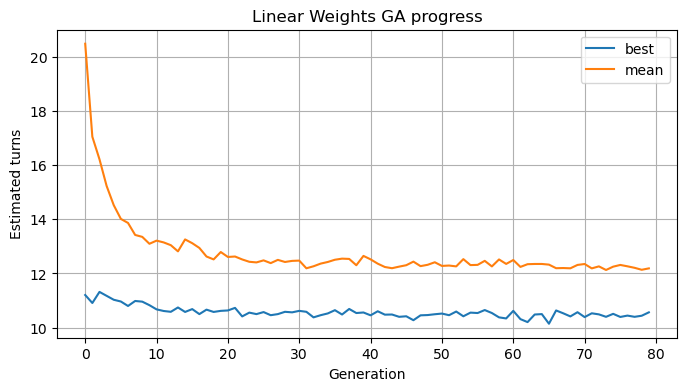

In [27]:
plt.figure(figsize=(8, 4))

plt.plot(result["history_best"], label="best")
plt.plot(result["history_mean"], label="mean")

plt.xlabel("Generation")
plt.ylabel("Estimated turns")
plt.title("Linear Weights GA progress")
plt.legend()
plt.grid(True)

plt.show()


# 9. Less noisy final evaluation

The fitness during evolution is noisy because each genome is evaluated with a limited number of games.

Here we evaluate the final genome on more simulations.


In [28]:
final_scores = [
    simulate_game(best_bits)
    for _ in range(10000)
]


print("Final mean turns:", np.mean(final_scores))
print("Final std:", np.std(final_scores))
print("Median:", np.median(final_scores))
print("Min:", np.min(final_scores))
print("Max:", np.max(final_scores))


Final mean turns: 10.6188
Final std: 2.806864186240581
Median: 10.0
Min: 4
Max: 36


# 10. Compare to the paper's Linear Weights Champion

The paper gives the champion:

| Column | Progress | Move |
|---|---:|---:|
| 2,12 | 7 | $64x + 7$ |
| 3,11 | 6 | $24x + 1$ |
| 4,10 | 4 | $28x + 2$ |
| 5,9 | 3 | $8x + 1$ |
| 6,8 | 2 | $18x + 3$ |
| 7 | 1 | $12x + 4$ |

Difficulty scores:
- odds: 1
- evens: 0
- highs/lows: -4
- marker: 4
- threshold: 24

The function below hard-codes this champion so we can test our simulator against it.


In [29]:
def paper_linear_champion_genome():
    progress_left = {
        2: 7,
        3: 6,
        4: 4,
        5: 3,
        6: 2,
        7: 1,
    }

    slopes_left = {
        2: 64,
        3: 24,
        4: 28,
        5: 8,
        6: 18,
        7: 12,
    }

    intercepts_left = {
        2: 7,
        3: 1,
        4: 2,
        5: 1,
        6: 3,
        7: 4,
    }

    progress = {}
    slopes = {}
    intercepts = {}

    for c in LEFT_COLUMNS:
        cm = mirror_column(c)

        progress[c] = progress_left[c]
        progress[cm] = progress_left[c]

        slopes[c] = slopes_left[c]
        slopes[cm] = slopes_left[c]

        intercepts[c] = intercepts_left[c]
        intercepts[cm] = intercepts_left[c]

    return {
        "progress_weights": progress,
        "slopes": slopes,
        "intercepts": intercepts,
        "even_bonus": 0,
        "odd_bonus": 1,
        "high_low_bonus": -4,
        "marker_penalty": 4,
        "threshold": 24,
    }


def simulate_game_from_decoded_genome(genome, max_turns=200):
    permanent = {c: 0 for c in COLUMNS}
    turns = 0

    while turns < max_turns:

        turns += 1
        neutral = {}

        while True:

            dice = roll_dice()
            moves = legal_moves(dice, permanent, neutral)

            if len(moves) == 0:
                break

            move = choose_move(moves, permanent, neutral, genome)

            for col in move:
                neutral[col] = neutral.get(col, permanent[col]) + 1
                neutral[col] = min(neutral[col], HEIGHT[col])

            if should_stop(permanent, neutral, genome):

                for col, pos in neutral.items():
                    permanent[col] = max(permanent[col], pos)

                break

        completed = sum(
            permanent[c] >= HEIGHT[c]
            for c in COLUMNS
        )

        if completed >= 3:
            return turns

    return max_turns


In [30]:
paper_genome = paper_linear_champion_genome()

paper_scores = [
    simulate_game_from_decoded_genome(paper_genome)
    for _ in range(1000)
]

print("Paper champion, simulated mean:", np.mean(paper_scores))
print("Paper champion, simulated std:", np.std(paper_scores))


Paper champion, simulated mean: 10.77
Paper champion, simulated std: 2.591736869360005


# 11. Display a compact genome table

In [31]:
def genome_table(genome):
    rows = []

    for c in LEFT_COLUMNS:
        rows.append({
            "columns": f"{c},{mirror_column(c)}" if c != 7 else "7",
            "progress": genome["progress_weights"][c],
            "slope": genome["slopes"][c],
            "intercept": genome["intercepts"][c],
        })

    return rows


genome_table(best_genome)


[{'columns': '2,12', 'progress': 6, 'slope': 64.0, 'intercept': 4},
 {'columns': '3,11', 'progress': 6, 'slope': 40.0, 'intercept': 3},
 {'columns': '4,10', 'progress': 3, 'slope': 48.0, 'intercept': 3},
 {'columns': '5,9', 'progress': 4, 'slope': 34.0, 'intercept': 0},
 {'columns': '6,8', 'progress': 2, 'slope': 52.0, 'intercept': 3},
 {'columns': '7', 'progress': 3, 'slope': 44.0, 'intercept': 3}]